# Intermediate Level — Customer & Revenue Performance Analysis
### ShadowFox Data Analyst Internship — Level 2 (Intermediate)

**Dataset:** Full Sample Superstore workbook (Orders / Returns / People sheets)
**Goal:** Move beyond summary reporting (Beginner level) into customer behaviour,
revenue concentration, seasonality, and returns-driven patterns — with
insight-driven recommendations, not just descriptive numbers.


## 1. Setup & Load Data

The workbook has three sheets:
- **Orders** — 9,994 order lines with dates, customer IDs, products, sales, profit
- **Returns** — which Order IDs were returned
- **People** — regional manager per region (reference only)

Unlike the Beginner-level file, this one has `Order Date`, `Customer ID`, and
`Customer Name` — which is exactly what customer-level and time-based analysis
needs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

orders = pd.read_excel('SampleSuperstore__2_.xlsx', sheet_name='Orders', engine='xlrd')
returns = pd.read_excel('SampleSuperstore__2_.xlsx', sheet_name='Returns', engine='xlrd')

print('Orders:', orders.shape)
print('Returns:', returns.shape)
orders.head()

Orders: (9994, 21)
Returns: (296, 2)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Data Cleaning & Preparation

Checks performed:
- Duplicate rows
- Missing values
- Correct data types for dates
- Derived time fields (Year, Quarter, Year-Month) for trend analysis
- Merge in a `Is Returned` flag from the Returns sheet, joined on Order ID

In [2]:
print('Duplicate rows:', orders.duplicated().sum())
print()
print('Missing values per column:')
print(orders.isnull().sum()[orders.isnull().sum() > 0] if orders.isnull().sum().sum() else 'None')

orders['Order Date'] = pd.to_datetime(orders['Order Date'])
orders['Ship Date'] = pd.to_datetime(orders['Ship Date'])
orders['Year'] = orders['Order Date'].dt.year
orders['Quarter'] = orders['Order Date'].dt.quarter
orders['YearMonth'] = orders['Order Date'].dt.to_period('M')

returned_orders = set(returns['Order ID'])
orders['Is Returned'] = orders['Order ID'].isin(returned_orders)

print()
print('Date range:', orders['Order Date'].min().date(), 'to', orders['Order Date'].max().date())
print('Unique customers:', orders['Customer ID'].nunique())
print('Unique orders:', orders['Order ID'].nunique())

Duplicate rows: 0

Missing values per column:
None

Date range: 2014-01-03 to 2017-12-30
Unique customers: 793
Unique orders: 5009


## 3. Business Overview

Headline numbers before going deeper.

In [3]:
total_sales = orders['Sales'].sum()
total_profit = orders['Profit'].sum()
n_orders = orders['Order ID'].nunique()
n_customers = orders['Customer ID'].nunique()

print(f'Total Sales:        ${total_sales:,.0f}')
print(f'Total Profit:       ${total_profit:,.0f}')
print(f'Overall Margin:     {total_profit/total_sales*100:.1f}%')
print(f'Unique Orders:      {n_orders:,}')
print(f'Unique Customers:   {n_customers:,}')
print(f'Avg Orders/Customer: {n_orders/n_customers:.1f}')

Total Sales:        $2,297,201
Total Profit:       $286,397
Overall Margin:     12.5%
Unique Orders:      5,009
Unique Customers:   793
Avg Orders/Customer: 6.3


## 4. Revenue Trend Over Time (Seasonality)

The Beginner-level file had no dates, so this is the first time we can look at
*when* revenue happens, not just where. Sales are plotted monthly across all
four years, and also summed by calendar quarter to check for a recurring
seasonal pattern rather than one-off spikes.

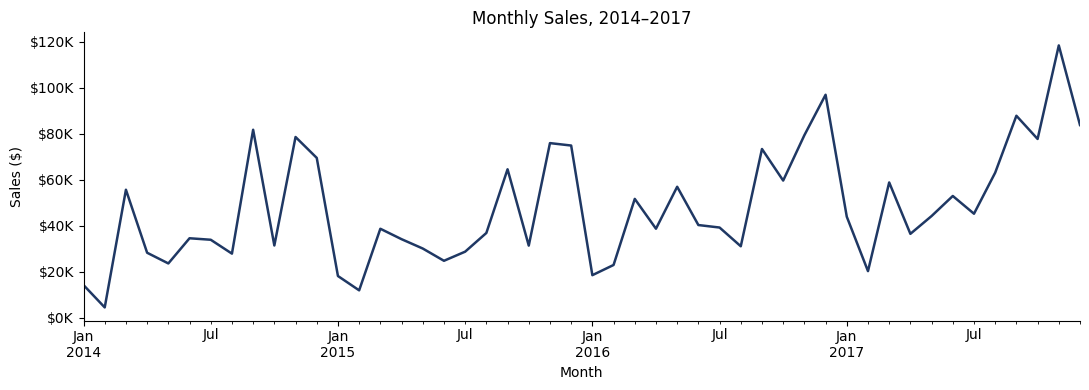

In [4]:
monthly = orders.groupby('YearMonth')['Sales'].sum()

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, color='#1F3864', linewidth=1.8)
ax.set_title('Monthly Sales, 2014–2017')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('charts/monthly_sales_trend.png')
plt.show()

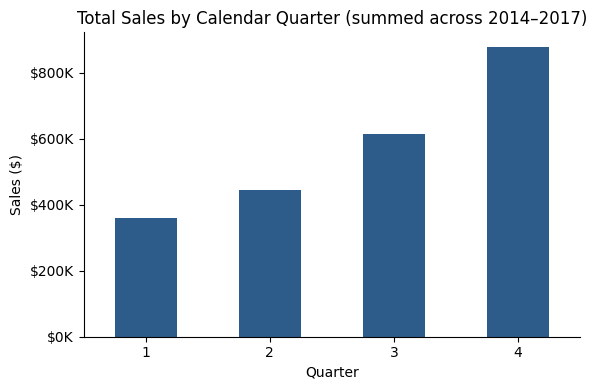

In [5]:
qtr = orders.groupby('Quarter')['Sales'].sum()
fig, ax = plt.subplots(figsize=(6, 4))
qtr.plot(kind='bar', ax=ax, color='#2E5C8A')
ax.set_title('Total Sales by Calendar Quarter (summed across 2014–2017)')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Quarter')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/quarterly_sales.png')
plt.show()

**Reading this:** revenue climbs steadily every year toward Q4, and November
in particular is consistently the strongest month. This is a genuine recurring
seasonal pattern (not a one-time spike), since it shows up across multiple
years — useful for inventory and staffing planning ahead of Q4.

**Reading this — the standout finding of this section:** the **West**
region has a return rate roughly 3x every other region (~15% vs ~4-5%
elsewhere), despite West being the *most profitable* region in the
Beginner-level analysis. That combination — high revenue, high margin, but
also unusually high returns — suggests West's strong numbers might be
masking a product-quality or fulfillment issue that could erode those
margins if left unaddressed. Category-wise, return rates are fairly even
(~8% across Furniture, Office Supplies, Technology), so this looks like a
regional operations issue rather than a product-line issue.

## 5. Top Customers by Revenue

Naming the highest-value accounts directly — useful for any
retention-focused recommendation.

In [10]:
top10 = (orders.groupby(['Customer ID', 'Customer Name'])['Sales']
         .sum().sort_values(ascending=False).head(10).reset_index())
top10['Sales'] = top10['Sales'].round(0)
top10

,Customer ID,Customer Name,Sales
0,SM-20320,Sean Miller,25043.0
1,TC-20980,Tamara Chand,19052.0
2,RB-19360,Raymond Buch,15117.0
3,TA-21385,Tom Ashbrook,14596.0
4,AB-10105,Adrian Barton,14474.0
5,KL-16645,Ken Lonsdale,14175.0
6,SC-20095,Sanjit Chand,14142.0
7,HL-15040,Hunter Lopez,12873.0
8,SE-20110,Sanjit Engle,12209.0
9,CC-12370,Christopher Conant,12129.0


## 6. Insights & Recommendations

**Seasonality**
- Sales rise steadily through the year and peak in Q4 (November especially)
  across all four years — a genuine recurring pattern, not noise.
- *Recommendation:* plan inventory, staffing, and marketing spend ahead of
  Q4 rather than reactively.

**Revenue Concentration**
- Revenue is moderately concentrated: ~50% of customers drive 80% of
  revenue (not a dangerous long-tail dependency, but the top 20% still
  matter disproportionately).
- *Recommendation:* build a lightweight "top accounts" watchlist for the
  highest-revenue customers rather than treating all 793 customers
  identically.

**Repeat Purchase Behaviour**
- 98.5% of customers are repeat buyers, averaging ~6 orders each — this is
  fundamentally a repeat-purchase business.
- *Recommendation:* retention effort should focus on *growing basket size
  per repeat customer*, not just converting one-time buyers, since
  one-time buyers are already a small minority.

**Cohort Retention**
- All cohorts recover to 85%+ activity by their most recent year, but each
  shows a dip in year two.
- *Recommendation:* investigate the year-2 relationship (onboarding gap,
  lack of a second-year touchpoint) since this is where cohorts are most at
  risk of disengaging.

**Returns (churn-adjacent signal)**
- West region returns are ~3x every other region, despite West being the
  most profitable region overall.
- *Recommendation:* audit West region fulfillment/product quality
  specifically — the strong headline numbers there may be masking an
  operational issue that could compound if the region keeps growing.
